# Task 1: Detect monitor edges

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'images/computers.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img.shape

(798, 2048, 3)

In [3]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)
edges[:150] = 0


def draw_lines(image, lines, tol=12):
    out = image.copy()
    kept = 0
    for x1, y1, x2, y2 in lines.reshape(-1, 4):
        angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
        if angle < tol or angle > 180 - tol or abs(angle - 90) < tol:
            cv2.line(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
            kept += 1
    return out, kept

In [4]:
votes = [40, 60, 80]
panels = [('Edges', edges)]

for v in votes:
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, v, minLineLength=40, maxLineGap=8)
    result, kept = draw_lines(img, lines)
    print(f'votes={v} - lines found:', len(lines), 'horizontal/vertical:', kept)
    panels.append((f'Votes={v}', result))

votes=40 - lines found: 160 horizontal/vertical: 152
votes=60 - lines found: 143 horizontal/vertical: 139
votes=80 - lines found: 129 horizontal/vertical: 126


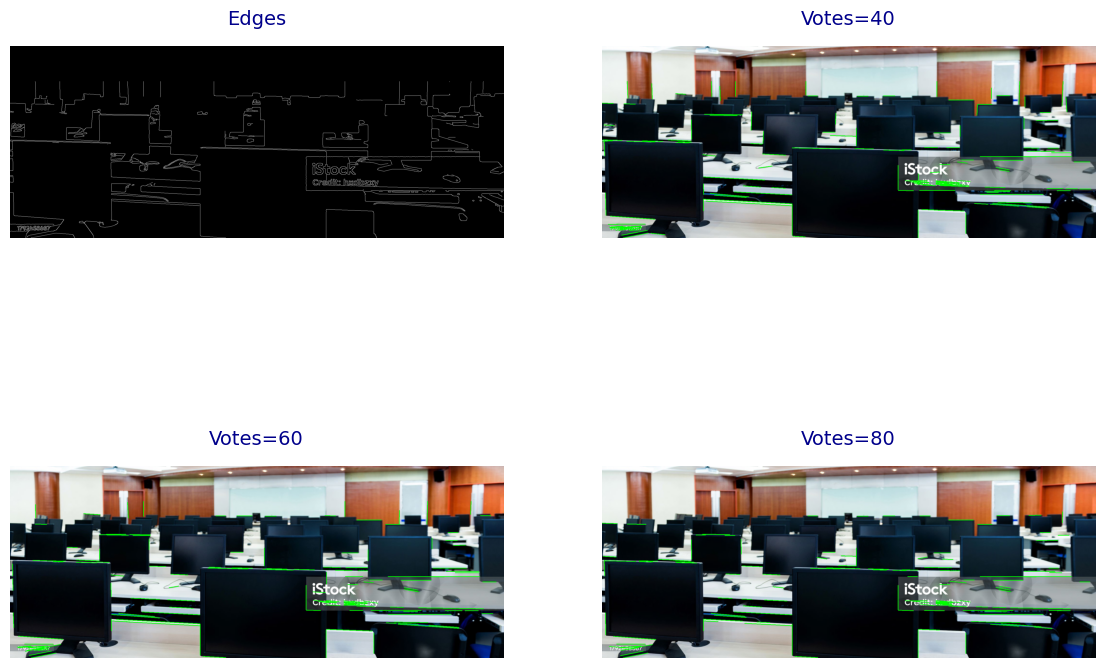

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()